# Define Helper Functions

In [95]:
import pandas as pd
import os
from functools import reduce
import numpy as np
from collections import defaultdict
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    make_scorer
)
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime
import json

# This function loads multiple feature files and merges them into one big table.
# Each file contains measurements for different participants, conditions, and time windows.
def load_and_merge_features(file_list, feature_dir='data'):
    base_keys = ['participant', 'condition', 'window_index', 'phase']
    dfs = []

    for fname, phase in file_list:
        full = os.path.join(feature_dir, fname)
        df   = pd.read_csv(full)
        df['phase'] = phase  # Mark which phase (e.g., baseline or experimental) this data is from

        # Make sure the file has the required columns
        if not all(k in df.columns for k in ['participant', 'condition', 'window_index']):
            raise ValueError(f"{fname} missing required keys")

        # If the file is in a "long" format (RQA-style), reshape it to "wide" format
        if 'column' in df.columns:
            id_vars = ['participant', 'condition', 'window_index', 'phase', 'column']
            value_vars = [col for col in df.columns if col not in id_vars + ['window_start', 'window_end']]
            df_long = df.melt(id_vars=id_vars, value_vars=value_vars,
                              var_name='metric', value_name='value')

            df_pivot = df_long.pivot_table(
                index=['participant', 'condition', 'window_index', 'phase'],
                columns=['column', 'metric'],
                values='value'
            )

            # Rename columns to make them easier to use
            df_pivot.columns = [f"{col1}__{col2}" for col1, col2 in df_pivot.columns]
            df = df_pivot.reset_index()
        else:
            # Remove unnecessary columns
            if 'window_start' in df.columns:
                df = df.drop(columns=['window_start'])

            prefix = os.path.splitext(os.path.basename(fname))[0]
            skip = base_keys + ['window_start']
            feats = [c for c in df.columns if c not in skip]
            # Rename columns to include the file name as a prefix
            df.rename(columns={c: f"{prefix}__{c}" for c in feats}, inplace=True)

        dfs.append(df)

    # Merge all dataframes together, matching on participant, condition, window, and phase
    merged = reduce(lambda L, R: pd.merge(L, R, on=base_keys, how='outer'), dfs)
    return merged.fillna(0)  # Fill missing values with zero

# This function randomly splits the data into training and testing sets.
# Used to check how well the model works on unseen data.
def split_random_windows(df, test_size=0.2, random_state=42):
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )
    return train_df, test_df

# This function splits the data so that some participants are used for training, and others for testing.
def split_by_participants(df, test_size=0.2, random_state=42, participant_col='participant'):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, groups=df[participant_col]))
    return df.iloc[train_idx], df.iloc[test_idx]

# This function creates incremental splits for baseline vs experimental phases.
# It helps test how adding more experimental data affects model performance.
def split_baseline_experimental_incremental(
        df, 
        phase_col='phase',
        baseline_phase='baseline',
        experimental_phase='experimental',
        window_col='window_index'
):
    base_df = df[df[phase_col]==baseline_phase]
    exp_df = df[df[phase_col]==experimental_phase]

    uniq = sorted(exp_df[window_col].unique())[::2]
    splits = []
    for k in range(len(uniq)+1):
        use=set(uniq[:k])
        train = pd.concat([
            base_df,
            exp_df[exp_df[window_col].isin(use)]
        ], ignore_index=True)
        test = exp_df[~exp_df[window_col].isin(use)].reset_index(drop=True)
        splits.append((train, test, k))
    return splits

# This function selects the best features (measurements) to use for prediction.
# It tries adding or removing groups of features and checks which combination works best.
def select_features(
        df,
        feature_cols,
        label_col='condition',
        method='forward',
        level='group',
        stopping='drop',
        verbose=True
    ):
        def get_groups(cols):
            # Get the list of feature groups (e.g., all metrics for a signal)
            return sorted({c.split('__')[0] for c in cols}) if level == 'group' else sorted(cols)

        def get_group_columns(group, cols):
            # Get all columns belonging to a group
            return [c for c in cols if c.startswith(group + '__')] if level == 'group' else [group]

        def evaluate_feature_set(cols):
            # Train a model and check its accuracy using cross-validation
            X, y = df[cols], df[label_col]
            rf = RandomForestClassifier(random_state=42)
            cv = StratifiedKFold(5, shuffle=True, random_state=42)
            scores = cross_validate(rf, X, y, cv=cv,
                                    scoring={'bal_acc': 'balanced_accuracy'})
            return np.mean(scores['test_bal_acc'])

        available = get_groups(feature_cols)
        best_score = -np.inf
        current = available.copy() if method == 'backward' else []
        history = []
        improving = True

        if verbose:
            print(f"\n=== Feature selection: {method} on {level}s ===")

        # Try adding/removing groups and keep track of the best combination
        while improving and available:
            candidates = []
            for g in available:
                trial = (current + [g]) if method == 'forward' else [x for x in current if x != g]
                cols = [f for grp in trial for f in get_group_columns(grp, feature_cols)]
                score = evaluate_feature_set(cols)
                candidates.append((score, g, trial))

            candidates.sort(reverse=True, key=lambda x: x[0])
            top_score, top_grp, top_trial = candidates[0]
            history.append((top_score, top_trial.copy()))

            if method == 'forward':
                if top_score > best_score:
                    best_score, current = top_score, top_trial
                    available.remove(top_grp)
                else:
                    improving = False if stopping == 'drop' else available.remove(top_grp)
            else:
                if top_score >= best_score:
                    best_score, current = top_score, top_trial
                    available.remove(top_grp)
                else:
                    improving = False if stopping == 'drop' else available.remove(top_grp)

        if stopping == 'best':
            best_score, current = max(history, key=lambda x: x[0])

        selected_features = [f for grp in current for f in get_group_columns(grp, feature_cols)]
        
        if verbose:
            print(f"✔ Selected {len(current)} {level}(s): {current}")
        return selected_features

# This function trains a Random Forest model to classify workload conditions.
# It can use different strategies for splitting data, select features, and show plots.
def train_random_forest(
    df,
    split_strategy='random',
    test_size=0.2,
    train_duration_sec=6*60,
    n_seeds=10,
    label_col='condition',
    use_pca=False,
    pca_variance=0.95,
    feature_selection=None,
    selection_level='group',
    selection_stopping='drop',
    show_plots=False,
    output_dir=None
):
    df = df.copy()
    id_cols = ['participant', 'condition', 'window_index']
    all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in all_numeric if c not in id_cols]

    classes = sorted(df[label_col].unique())
    n_classes = len(classes)

    def get_groups(cols):
        if selection_level == 'group':
            return sorted({c.split('__')[0] for c in cols})
        return sorted(cols)

    def get_group_columns(group, cols):
        if selection_level == 'group':
            return [c for c in cols if c.startswith(group + '__')]
        return [group]

    def evaluate_feature_set(cols):
        X, y = df[cols], df[label_col]
        rf = RandomForestClassifier(random_state=42)
        cv = StratifiedKFold(5, shuffle=True, random_state=42)
        scores = cross_validate(rf, X, y, cv=cv,
                                 scoring={'bal_acc': 'balanced_accuracy'})
        return np.mean(scores['test_bal_acc'])

    # If feature selection is requested, run it first
    if feature_selection in ('forward','backward'):
        print(f"\n=== Running {feature_selection} selection on {selection_level}s ===")
        available = get_groups(feature_cols)
        best_score = -np.inf
        current = available.copy() if feature_selection=='backward' else []
        history = []
        improving = True

        while improving and available:
            candidates = []
            for g in tqdm(available, desc=f"{feature_selection.title()} Selection", leave=False):
                trial = (current + [g]) if feature_selection=='forward' else [x for x in current if x!=g]
                cols = [feat for grp in trial for feat in get_group_columns(grp, feature_cols)]
                score = evaluate_feature_set(cols)
                candidates.append((score, g, trial))
            candidates.sort(reverse=True, key=lambda x:x[0])
            top_score, top_grp, top_trial = candidates[0]
            history.append((top_score, top_trial.copy()))

            if feature_selection=='forward':
                if top_score>best_score:
                    best_score, current = top_score, top_trial
                    available.remove(top_grp)
                else:
                    if selection_stopping=='drop': improving=False
                    else: available.remove(top_grp)
            else:
                if top_score>=best_score:
                    best_score, current = top_score, top_trial
                    available.remove(top_grp)
                else:
                    if selection_stopping=='drop': improving=False
                    else: available.remove(top_grp)

        if selection_stopping=='best':
            best_score, current = max(history, key=lambda x:x[0])

        print(f"Selected {len(current)} {selection_level}(s): {current}")
        feature_cols = [f for grp in current for f in get_group_columns(grp, feature_cols)]

    # Main training loop: repeat with different random seeds for reliability
    metrics = defaultdict(list)
    cm_sum  = np.zeros((n_classes, n_classes))
    imp_acc = defaultdict(list)

    is_single_group = (
        selection_level == 'group' and
        len({f.split('__')[0] for f in feature_cols}) == 1 and
        not use_pca
    )

    for seed in range(n_seeds):
        # Split the data into training and testing sets
        adapt = None
        if split_strategy == 'random':
            tr, te = split_random_windows(df, test_size, seed)
        elif split_strategy == 'participant':
            tr, te = split_by_participants(df, test_size, seed)
        elif split_strategy == 'fewshot':
            # now returns (train_df, test_df, adapt_df)
            tr, te, adapt = split_fewshot(
                df,
                participant_col='participant',
                phase_col='phase',
                test_size=test_size,
                random_state=seed
            )
        elif split_strategy == 'pre_main':          
            tr, te = split_pre_vs_main(df, phase_col='phase')
        else:
            tr, te = split_temporal(df, train_duration_sec)

        X_tr, y_tr = tr[feature_cols], tr[label_col]
        X_te, y_te = te[feature_cols], te[label_col]

        # Train the Random Forest model
        rf = RandomForestClassifier(random_state=seed)
        rf.fit(X_tr, y_tr)

        # If using "fewshot" strategy, calibrate the model with a small adaptation set
        if split_strategy == 'fewshot' and adapt is not None and not adapt.empty:
            from sklearn.calibration import CalibratedClassifierCV
            calibrator = CalibratedClassifierCV(rf, method='isotonic', cv='prefit')
            X_adapt = adapt[feature_cols]
            y_adapt = adapt[label_col]
            calibrator.fit(X_adapt, y_adapt)
            y_pred = calibrator.predict(X_te)
        else:
            y_pred = rf.predict(X_te)

        # Optionally, reduce features using PCA (Principal Component Analysis)
        if use_pca:
            parts_tr, parts_te = [], []
            for grp in get_groups(feature_cols):
                cols = get_group_columns(grp, feature_cols)
                scaler = StandardScaler()
                Xt = scaler.fit_transform(X_tr[cols])
                Xe = scaler.transform(X_te[cols])
                p = PCA(pca_variance, svd_solver='full', random_state=seed)
                Xt_p = p.fit_transform(Xt)
                Xe_p = p.transform(Xe)
                names = [f"{grp}_pc{i}" for i in range(p.n_components_)]
                parts_tr.append(pd.DataFrame(Xt_p, columns=names, index=X_tr.index))
                parts_te.append(pd.DataFrame(Xe_p, columns=names, index=X_te.index))
            X_tr = pd.concat(parts_tr, axis=1)
            X_te = pd.concat(parts_te, axis=1)

        # Cross-validate the model and collect performance metrics
        rf = RandomForestClassifier(random_state=seed)
        cv = StratifiedKFold(5, shuffle=True, random_state=seed)
        cv_res = cross_validate(rf, X_tr, y_tr, cv=cv,
                                scoring={
                                  'acc':'accuracy',
                                  'bal_acc':'balanced_accuracy',
                                  'f1':'f1_macro',
                                  'kappa':make_scorer(cohen_kappa_score)
                                })
        metrics['cv_acc'].append(cv_res['test_acc'].mean())
        metrics['cv_bal_acc'].append(cv_res['test_bal_acc'].mean())
        metrics['cv_f1'].append(cv_res['test_f1'].mean())
        metrics['cv_kappa'].append(cv_res['test_kappa'].mean())

        # Train and test the model on the split data
        rf.fit(X_tr, y_tr)
        y_pred = rf.predict(X_te)
        metrics['test_acc'].append(accuracy_score(y_te,y_pred))
        metrics['test_bal_acc'].append(balanced_accuracy_score(y_te,y_pred))
        metrics['test_f1'].append(f1_score(y_te,y_pred,average='macro'))
        metrics['test_kappa'].append(cohen_kappa_score(y_te,y_pred))

        cm_sum += confusion_matrix(y_te, y_pred, labels=classes)

        # Collect feature importances (which measurements matter most for prediction)
        for feat, imp in zip(X_te.columns, rf.feature_importances_):
            if selection_level=='metric' and not use_pca:
                imp_acc[feat].append(imp)
            elif is_single_group:
                imp_acc[feat].append(imp)
            else:
                grp = feat.split('_pc')[0] if use_pca else feat.split('__')[0]
                imp_acc[grp].append(imp)

    # Print summary of model performance
    print("\n=== CV Metrics ===")
    for k in ['cv_acc','cv_bal_acc','cv_f1','cv_kappa']:
        print(f"{k}: {np.mean(metrics[k]):.3f}")
    print("\n=== Test Metrics ===")
    for k in ['test_acc','test_bal_acc','test_f1','test_kappa']:
        print(f"{k}: {np.mean(metrics[k]):.3f}")

    # Package results for saving or further analysis
    results = {
        'metrics':   {k: np.mean(v) for k, v in metrics.items()},
        'cm_sum':    cm_sum,
        'imp_acc':   dict(imp_acc),
        'classes':   classes,
        'feature_cols': feature_cols
    }

    # Save results to a JSON file if requested
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        with open(os.path.join(output_dir, 'results.json'), 'w') as f:
            # Convert numpy types to native Python types for JSON serialization
            def convert(obj):
                if isinstance(obj, np.ndarray):
                    return obj.tolist()
                if isinstance(obj, np.generic):
                    return obj.item()
                return obj
            json.dump(
                {k: convert(v) for k, v in results.items()},
                f,
                indent=2
            )

    # Optionally, show plots of model results
    if show_plots:
        # Plot confusion matrix (shows how well the model distinguishes between classes)
        cm_prop = cm_sum / cm_sum.sum(axis=1, keepdims=True)
        annot   = np.array([[f"{v:.1f}%" for v in row*100] for row in cm_prop])
        plt.figure(figsize=(6,5))
        sns.heatmap(cm_prop*100, annot=annot, fmt='s',
                    xticklabels=classes, yticklabels=classes,
                    vmin=0, vmax=100, cmap='Blues')
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

        # Plot feature importances (which measurements matter most)
        metric_mode = (selection_level=='metric' and not use_pca)
        if metric_mode:
            avg_imp = {feat: np.mean(imp_acc[feat])
                       for feat in feature_cols if feat in imp_acc}
            labels, imps = zip(*sorted(avg_imp.items(), key=lambda x: x[1], reverse=True))
            title = "Feature Importances (Individual Metrics)"
        else:
            grp_imp = defaultdict(list)
            for key, imps in imp_acc.items():
                grp_imp[key].extend(imps)
            avg_imp = {g: np.mean(v) for g,v in grp_imp.items()}
            labels, imps = zip(*sorted(avg_imp.items(), key=lambda x: x[1], reverse=True))
            title = "Feature Group Importances"

        plt.figure(figsize=(8,5))
        sns.barplot(x=list(imps), y=list(labels))
        plt.xlabel("Mean Importance")
        plt.title(title)
        plt.tight_layout()
        if output_dir:
            fig_path = os.path.join(output_dir, 'confusion_matrix.png')  # or 'feature_importance.png'
            plt.savefig(fig_path)
            print(f"Saved plot to {fig_path}")
        else:
            plt.show()

    return results

# This function logs the model results to a CSV file for record-keeping.
# It avoids logging duplicate entries.
def log_rf_results_to_csv(
    metrics_dict,
    feature_groups_used,
    config,
    selected_items=None,
    log_path="model_eval_log.csv"
):
    """
    Logs the results from train_random_forest to a CSV file if not already logged.

    If feature elimination was used, `selected_items` should be a list of
    groups or metric names actually retained.
    """
    # Create a key for the feature groups used
    feature_key = "+".join(sorted(feature_groups_used))
    
    # Build the row to log
    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "feature_groups": feature_key,
        "split_strategy": config.get("split_strategy"),
        "feature_selection": config.get("feature_selection"),
        "selection_level": config.get("selection_level"),
        "selection_stopping": config.get("selection_stopping"),
        "pca_used": config.get("use_pca"),
        "pca_variance": config.get("pca_variance"),
        "n_seeds": config.get("n_seeds"),
        # If feature elimination was used, record the actual selected items
        "selected_items": "+".join(sorted(selected_items)) if selected_items else ""
    }
    # Add metrics to the row
    row.update(metrics_dict)

    # Read or create the log file
    if os.path.exists(log_path):
        log_df = pd.read_csv(log_path)
        # Check for duplicate entries
        duplicate_check = (
            (log_df['feature_groups'] == feature_key)
            & (log_df['split_strategy'] == row['split_strategy'])
            & (log_df['pca_used'] == row['pca_used'])
            & (log_df['feature_selection'] == row['feature_selection'])
        )
        if duplicate_check.any():
            print(f"[LOG] Skipping duplicate entry: {feature_key}, PCA={row['pca_used']}, "
                  f"Split={row['split_strategy']}, Selection={row['feature_selection']}")
            return
        log_df = pd.concat([log_df, pd.DataFrame([row])], ignore_index=True)
    else:
        log_df = pd.DataFrame([row])

    # Save the log to CSV
    log_df.to_csv(log_path, index=False)
    print(f"[LOG] Logged new entry: {feature_key}, PCA={row['pca_used']}, "
          f"Split={row['split_strategy']}, Selection={row['feature_selection']}")

# File paths

In [ ]:
# assumes all of these csvs are under data/
feature_groups = {
    "linear_pose_pre": [
        ("linear_pose_metrics/baseline_pose_metrics.csv", "pre")
    ],
    "performance_pre": [
        ("performance/performance_bsl.csv", "pre")
    ],
    "performance_main": [
        ("performance/performance_exp.csv", "main")
    ],
    "linear_pose_main": [
        ("linear_pose_metrics/experimental_pose_metrics.csv", "main")
    ],
    "rqa_pose_pre": [
        ("rqa/baseline_pose_rqa.csv", "pre")
    ],
    "rqa_pose_main": [
        ("rqa/experimental_pose_rqa.csv", "main")
    ]
}

selected_group = feature_groups["linear_pose_main"] + feature_groups["rqa_pose_main"] # merge different files together
merged_df = load_and_merge_features(selected_group)
print(merged_df.shape) # make sure it looks appropriate 
print(merged_df.columns[:10])

(3222, 152)
Index(['participant', 'condition', 'window_index',
       'experimental_pose_metrics__window_end',
       'experimental_pose_metrics__center_face_magnitude_mean_abs_vel',
       'experimental_pose_metrics__center_face_magnitude_mean_abs_acc',
       'experimental_pose_metrics__center_face_magnitude_rms',
       'experimental_pose_metrics__avg_pupil_magnitude_mean_abs_vel',
       'experimental_pose_metrics__avg_pupil_magnitude_mean_abs_acc',
       'experimental_pose_metrics__avg_pupil_magnitude_rms'],
      dtype='object')


# 4.3.1 Verification of Load Manipulations

In [59]:
selected_group = feature_groups["performance_main"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='random', 
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output'
)


=== Running forward selection on metrics ===


Selected 3 metric(s): ['performance_exp__track_point_accuracy', 'performance_exp__mean_comms_response_time', 'performance_exp__resman_point_accuracy']

=== CV Metrics ===
cv_acc: 0.537
cv_bal_acc: 0.536
cv_f1: 0.526
cv_kappa: 0.305

=== Test Metrics ===
test_acc: 0.536
test_bal_acc: 0.536
test_f1: 0.526
test_kappa: 0.304


In [ ]:
selected_group = feature_groups["performance_main"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', 
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=True
)

# 4.3.2 Linear Pose Features as Load Classifiers

In [ ]:
selected_group = feature_groups["linear_pose_main"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='random', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=True,
    output_dir='data/model_output'
)

In [ ]:
selected_group = feature_groups["linear_pose_main"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=True,
    output_dir='data/model_output'

## figs

Saved confusion matrix for 4_3_4_participant_linear_main_pre_perf to figs/cm/cm_4_3_4_participant_linear_main_pre_perf.svg


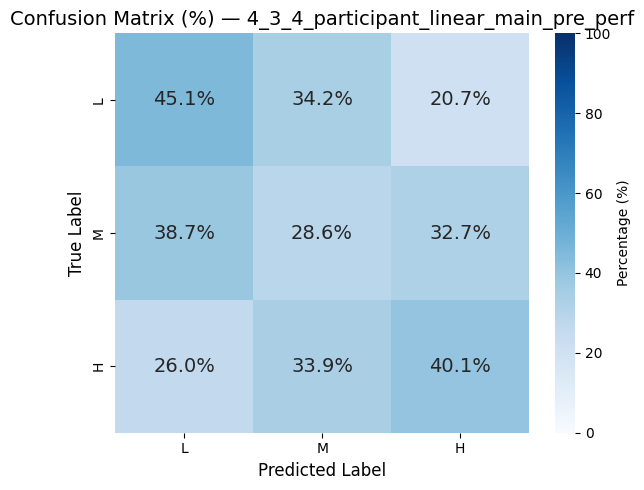

Saved confusion matrix for 4_3_4_random_linear_main_pre_perf to figs/cm/cm_4_3_4_random_linear_main_pre_perf.svg


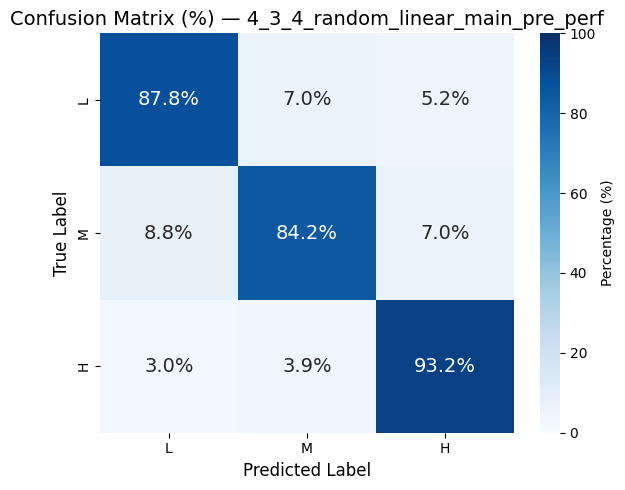

Saved confusion matrix for 4_3_3_random_rqa_linear to figs/cm/cm_4_3_3_random_rqa_linear.svg


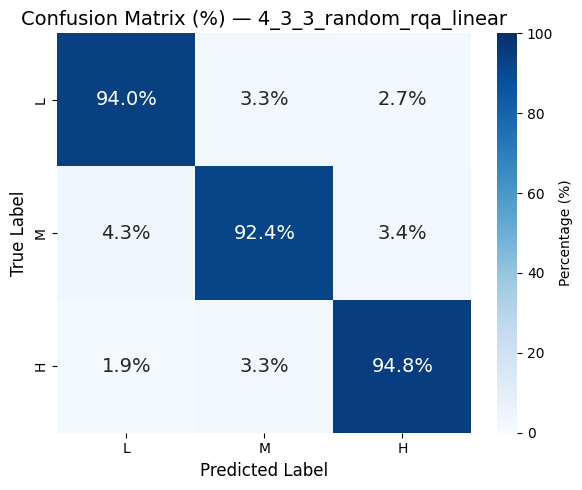

Saved confusion matrix for 4_3_2_random to figs/cm/cm_4_3_2_random.svg


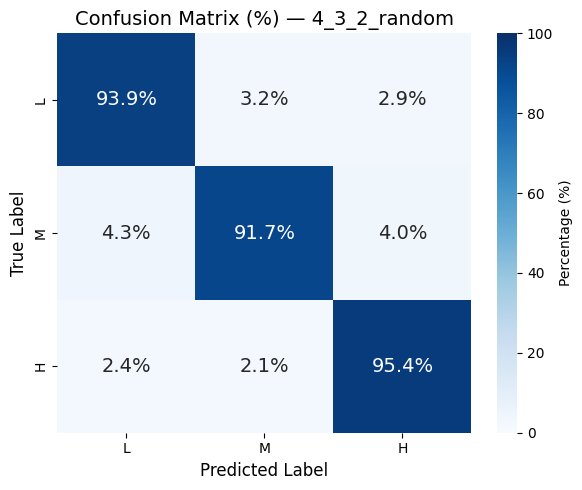

Saved confusion matrix for 4_3_3_participant_rqa_linear to figs/cm/cm_4_3_3_participant_rqa_linear.svg


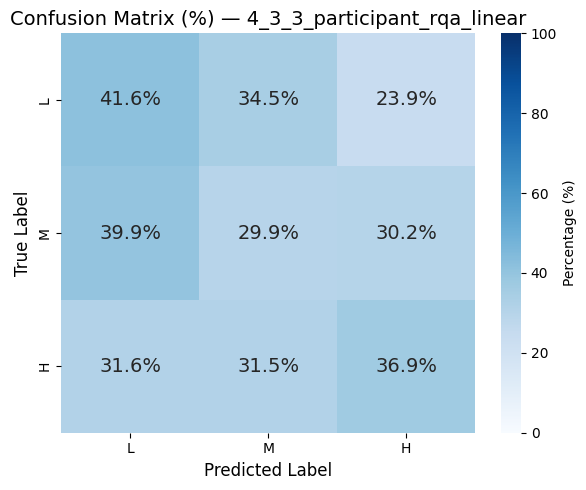

Saved confusion matrix for 4_3_1_random to figs/cm/cm_4_3_1_random.svg


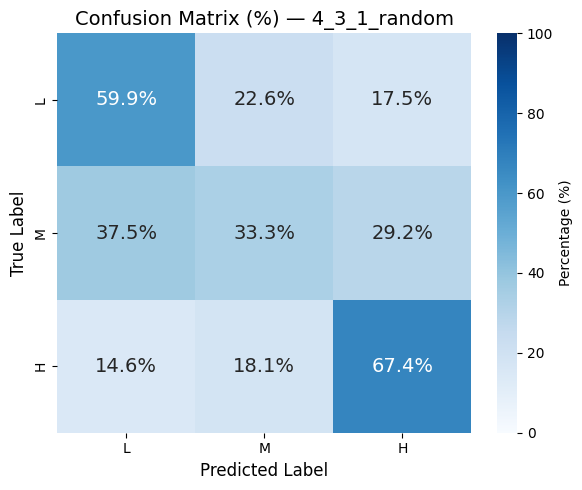

Saved confusion matrix for 4_3_4_participant_linear_main_pre_pose_perf to figs/cm/cm_4_3_4_participant_linear_main_pre_pose_perf.svg


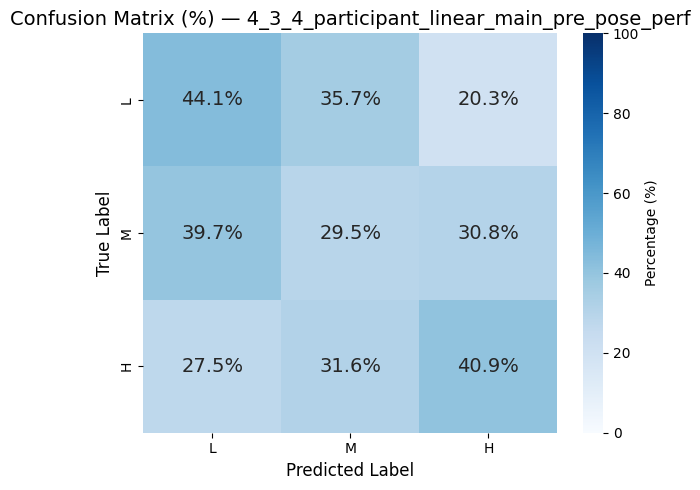

Saved confusion matrix for 4_3_4_random_linear_main_pre_pose_perf to figs/cm/cm_4_3_4_random_linear_main_pre_pose_perf.svg


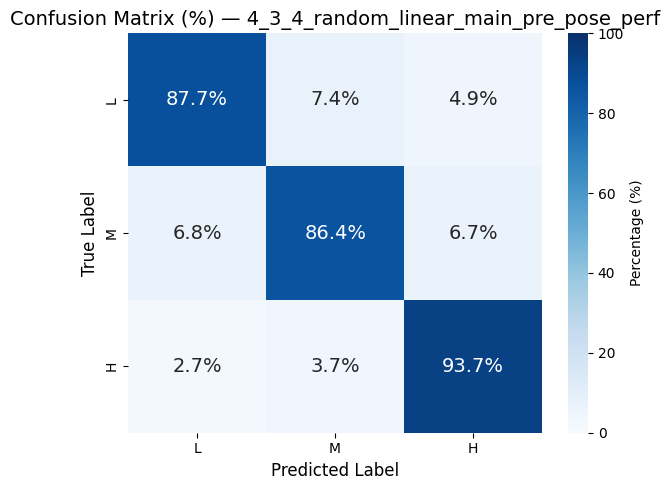

Saved confusion matrix for 4_3_3_random_rqa_alone to figs/cm/cm_4_3_3_random_rqa_alone.svg


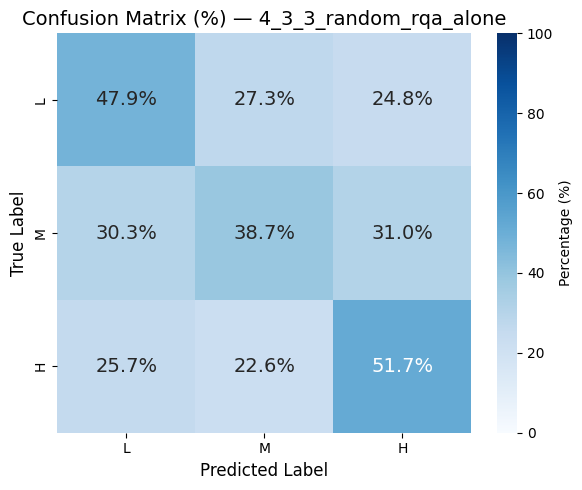

Saved confusion matrix for 4_3_2_participant to figs/cm/cm_4_3_2_participant.svg


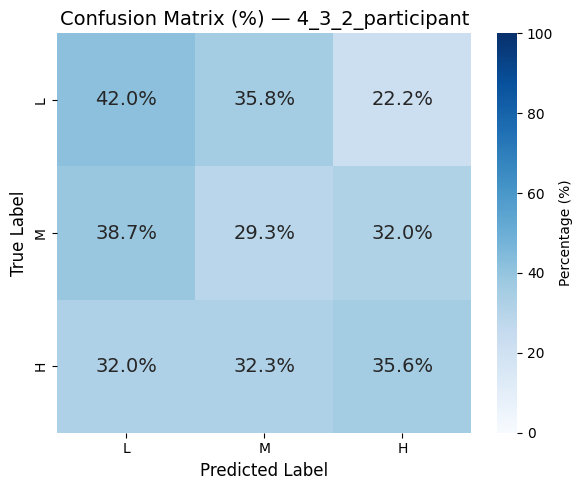

Saved confusion matrix for 4_3_4_random_linear_main_pre_pose to figs/cm/cm_4_3_4_random_linear_main_pre_pose.svg


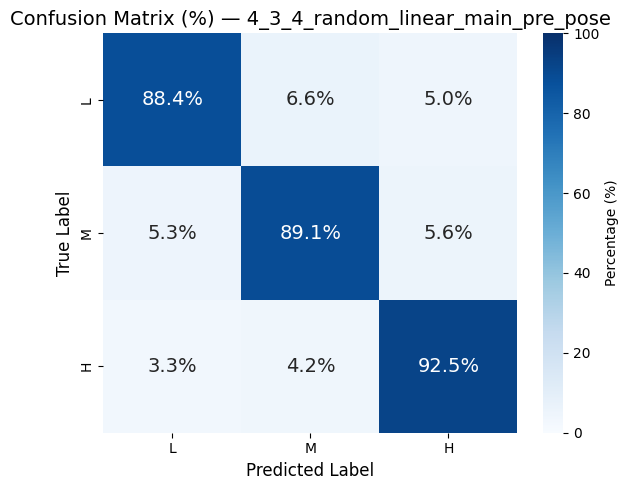

Saved confusion matrix for 4_3_4_participant_linear_main_pre_pose to figs/cm/cm_4_3_4_participant_linear_main_pre_pose.svg


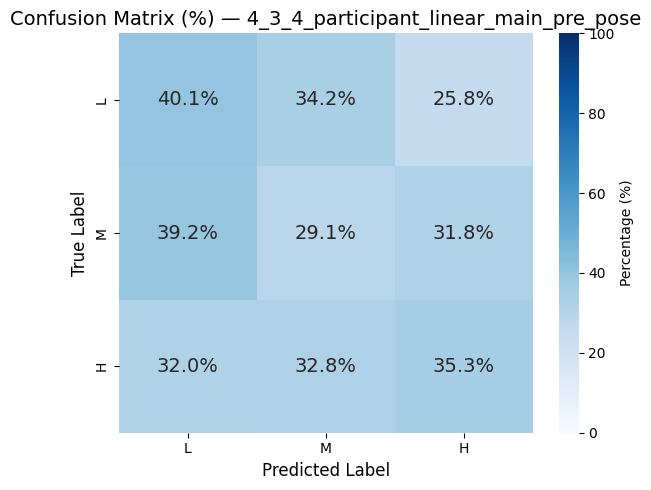

Saved confusion matrix for 4_3_3_participant_rqa_alone to figs/cm/cm_4_3_3_participant_rqa_alone.svg


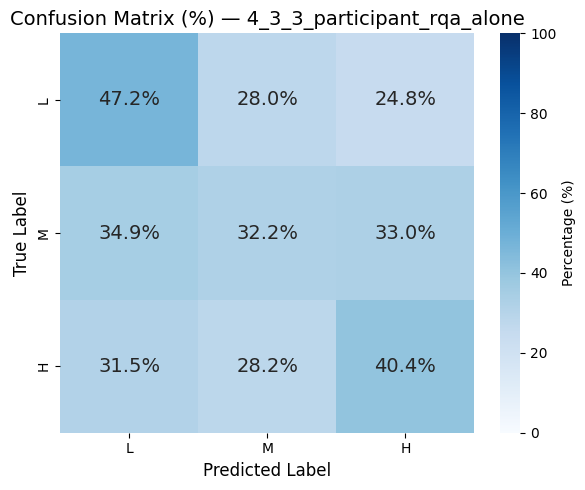

In [2]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Directory where your JSON files live
json_dir = "data/model_output"
json_pattern = os.path.join(json_dir, "*.json")

# Make output directory for confusion matrix figures
out_dir = "figs/cm"
os.makedirs(out_dir, exist_ok=True)

# Find all JSON files
json_files = glob.glob(json_pattern)

for json_path in json_files:
    # Load JSON
    with open(json_path, "r") as f:
        data = json.load(f)

    # Extract confusion matrix and class labels
    cm_raw = np.array(data["cm_sum"])
    labels = data.get("classes", None)

    # Normalize by row to get percentages
    cm = cm_raw.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(cm, row_sums, where=row_sums != 0) * 100
    desired_order = ["L", "M", "H"]
    if labels:
        indices = [labels.index(l) for l in desired_order if l in labels]
        cm_percent = cm_percent[indices][:, indices]
        labels = [labels[i] for i in indices]

    # Format with % signs
    annotations = np.array([["{:.1f}%".format(v) for v in row] for row in cm_percent])

    # Create figure
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm_percent,
        annot=annotations,
        fmt="",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        vmin=0,
        vmax=100,
        annot_kws={"size": 14},  # ← controls font size of the percentages
        cbar_kws={"label": "Percentage (%)"}
    )


    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    base = os.path.splitext(os.path.basename(json_path))[0]
    ax.set_title(f"Confusion Matrix (%) — {base}", fontsize=14)

    plt.tight_layout()
    out_path = os.path.join(out_dir, f"cm_{base}.svg")
    plt.savefig(out_path, dpi=300)
    print(f"Saved confusion matrix for {base} to {out_path}")
    plt.show()


# 4.3.3 Nonlinear Feature Comparison

In [23]:
selected_group = feature_groups["rqa_pose_main"] + feature_groups["linear_pose_main"]
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='random', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')


=== Running forward selection on metrics ===


Selected 9 metric(s): ['experimental_pose_metrics__blink_dist_mean_abs_acc', 'experimental_pose_metrics__head_rotation_angle_mean_abs_acc', 'experimental_pose_metrics__mouth_dist_mean_abs_acc', 'experimental_pose_metrics__avg_pupil_x_mean_abs_acc', 'experimental_pose_metrics__avg_pupil_y_mean_abs_acc', 'experimental_pose_metrics__head_rotation_angle_rms', 'experimental_pose_metrics__blink_dist_rms', 'experimental_pose_metrics__mouth_dist_rms', 'experimental_pose_metrics__avg_pupil_magnitude_mean_abs_vel']

=== CV Metrics ===
cv_acc: 0.920
cv_bal_acc: 0.920
cv_f1: 0.920
cv_kappa: 0.880

=== Test Metrics ===
test_acc: 0.938
test_bal_acc: 0.938
test_f1: 0.937
test_kappa: 0.906


## figs

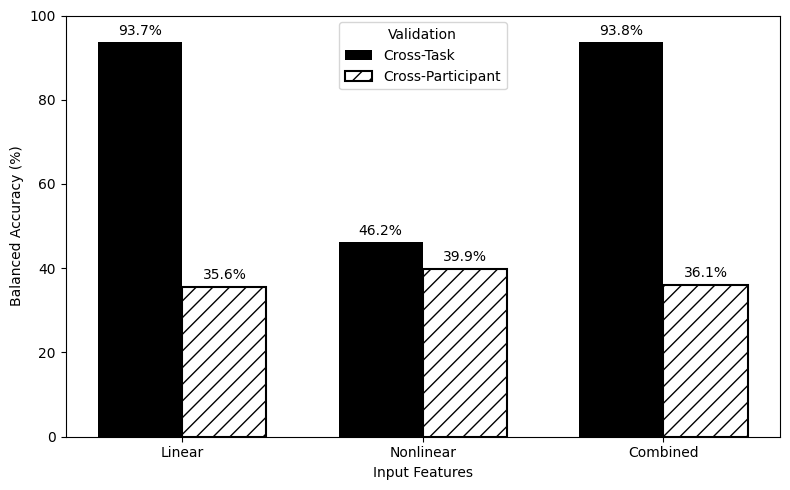

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# File paths per (Feature Set, Validation Strategy)
model_files = {
    ("Linear", "Cross-Task"): "data/model_output/4_3_2_random.json",
    ("Linear", "Cross-Participant"): "data/model_output/4_3_2_participant.json",
    ("Nonlinear", "Cross-Task"): "data/model_output/4_3_3_random_rqa_alone.json",
    ("Nonlinear", "Cross-Participant"): "data/model_output/4_3_3_participant_rqa_alone.json",
    ("Combined", "Cross-Task"): "data/model_output/4_3_3_random_rqa_linear.json",
    ("Combined", "Cross-Participant"): "data/model_output/4_3_3_participant_rqa_linear.json"
}

feature_sets = ["Linear", "Nonlinear", "Combined"]
cross_task_scores = []
cross_participant_scores = []

# Load test_bal_acc from each file
for fs in feature_sets:
    ct_path = model_files[(fs, "Cross-Task")]
    cp_path = model_files[(fs, "Cross-Participant")]
    
    with open(ct_path, 'r') as f:
        ct_data = json.load(f)
        ct_score = ct_data['metrics']['test_bal_acc'] * 100
    
    with open(cp_path, 'r') as f:
        cp_data = json.load(f)
        cp_score = cp_data['metrics']['test_bal_acc'] * 100

    cross_task_scores.append(ct_score)
    cross_participant_scores.append(cp_score)

# === Plotting ===
x = np.arange(len(feature_sets))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, cross_task_scores, width, label='Cross-Task', color='black')
bars2 = ax.bar(
    x + width/2,
    cross_participant_scores,
    width,
    label='Cross-Participant',
    hatch='//',
    edgecolor='black',
    facecolor='none',  # Use 'none' not 'white'
    linewidth=1.5      # Make hatch lines visible
)


# Annotate bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

# Labels
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_xlabel('Input Features')
ax.set_xticks(x)
ax.set_xticklabels(feature_sets)
ax.set_ylim(0, 100)
ax.legend(title='Validation')

plt.tight_layout()
plt.savefig("figs/linear_nl_model_comparison.svg")
plt.show()


# 4.3.4 Baseline Features

In [ ]:
selected_group = feature_groups["linear_pose_main"] + feature_groups["linear_pose_pre"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')

In [33]:
selected_group = feature_groups["linear_pose_main"] + feature_groups["performance_pre"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')


=== Running forward selection on metrics ===


Selected 15 metric(s): ['experimental_pose_metrics__blink_dist_rms', 'experimental_pose_metrics__head_rotation_angle_rms', 'experimental_pose_metrics__mouth_dist_mean_abs_vel', 'experimental_pose_metrics__head_rotation_angle_mean_abs_acc', 'experimental_pose_metrics__blink_dist_mean_abs_acc', 'experimental_pose_metrics__avg_pupil_x_mean_abs_acc', 'performance_bsl__track_point_accuracy', 'experimental_pose_metrics__avg_pupil_y_mean_abs_acc', 'experimental_pose_metrics__mouth_dist_rms', 'experimental_pose_metrics__avg_pupil_y_rms', 'experimental_pose_metrics__avg_pupil_magnitude_rms', 'performance_bsl__sysmon_point_accuracy', 'performance_bsl__resman_point_accuracy', 'performance_bsl__mean_comms_response_time', 'experimental_pose_metrics__center_face_y_mean_abs_vel']

=== CV Metrics ===
cv_acc: 0.876
cv_bal_acc: 0.876
cv_f1: 0.876
cv_kappa: 0.815

=== Test Metrics ===
test_acc: 0.379
test_bal_acc: 0.379
test_f1: 0.377
test_kappa: 0.069


In [63]:
selected_group = feature_groups["linear_pose_main"] + feature_groups["linear_pose_pre"] + feature_groups["performance_pre"]
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')


=== Running forward selection on metrics ===


Selected 17 metric(s): ['experimental_pose_metrics__blink_dist_rms', 'experimental_pose_metrics__mouth_dist_rms', 'experimental_pose_metrics__head_rotation_angle_mean_abs_acc', 'experimental_pose_metrics__blink_dist_mean_abs_vel', 'experimental_pose_metrics__mouth_dist_mean_abs_vel', 'experimental_pose_metrics__avg_pupil_x_mean_abs_acc', 'performance_bsl__track_point_accuracy', 'experimental_pose_metrics__head_rotation_angle_rms', 'experimental_pose_metrics__avg_pupil_y_mean_abs_vel', 'baseline_pose_metrics__avg_pupil_magnitude_mean_abs_acc', 'baseline_pose_metrics__head_rotation_angle_mean_abs_vel', 'baseline_pose_metrics__center_face_x_mean_abs_vel', 'baseline_pose_metrics__mouth_dist_mean_abs_vel', 'experimental_pose_metrics__avg_pupil_y_rms', 'performance_bsl__resman_point_accuracy', 'baseline_pose_metrics__blink_dist_mean_abs_vel', 'experimental_pose_metrics__blink_dist_mean_abs_acc']

=== CV Metrics ===
cv_acc: 0.896
cv_bal_acc: 0.896
cv_f1: 0.896
cv_kappa: 0.844

=== Test Metric

In [ ]:
selected_group = feature_groups["linear_pose_main"] + feature_groups["linear_pose_pre"] 
merged = load_and_merge_features(selected_group)

results = train_random_forest(
    merged,        
    split_strategy='participant', # change to participant if desired
    feature_selection='forward',   
    selection_level='metric',
    selection_stopping='drop',
    use_pca=False,
    n_seeds=10,
    show_plots=False,
    output_dir='data/model_output')

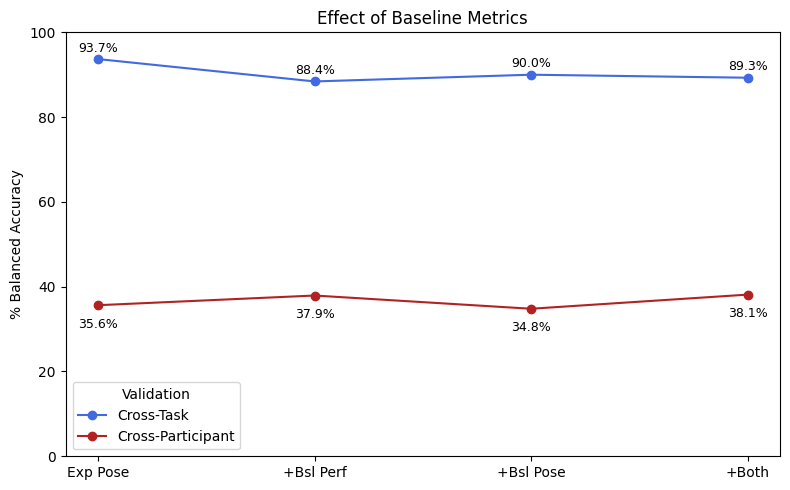

In [70]:
import json
import matplotlib.pyplot as plt

# === Step 1: Labels ===
conditions = ["Exp Pose", "+Bsl Perf", "+Bsl Pose", "+Both"]

# Hardcoded file paths for each validation scheme
windows_files = [
    "data/model_output/4_3_2_random.json",
    "data/model_output/4_3_4_random_linear_main_pre_perf.json",
    "data/model_output/4_3_4_random_linear_main_pre_pose.json",
    "data/model_output/4_3_4_random_linear_main_pre_pose_perf.json"
]

lop_files = [
    "data/model_output/4_3_2_participant.json",
    "data/model_output/4_3_4_participant_linear_main_pre_perf.json",
    "data/model_output/4_3_4_participant_linear_main_pre_pose.json",
    "data/model_output/4_3_4_participant_linear_main_pre_pose_perf.json"
]

# === Step 2: Load accuracy values ===
def extract_accuracy(file_list, key):
    accs = []
    for file in file_list:
        with open(file, 'r') as f:
            data = json.load(f)
            accs.append(data["metrics"][key] * 100)
    return accs

windows_acc = extract_accuracy(windows_files, "test_bal_acc")
lop_acc = extract_accuracy(lop_files, "test_bal_acc")

# === Step 3: Plotting ===
plt.figure(figsize=(8, 5))

plt.plot(conditions, windows_acc, marker='o', color='royalblue', label="Cross-Task")
plt.plot(conditions, lop_acc, marker='o', color='firebrick', label="Cross-Participant")

# Add annotations
for i, (w_acc, l_acc) in enumerate(zip(windows_acc, lop_acc)):
    plt.text(i, w_acc + 1, f"{w_acc:.1f}%", ha='center', va='bottom', fontsize=9)
    plt.text(i, l_acc - 3, f"{l_acc:.1f}%", ha='center', va='top', fontsize=9)

# Aesthetic
plt.ylim(0, 100)
plt.ylabel("% Balanced Accuracy")
plt.title("Effect of Baseline Metrics")
plt.legend(title="Validation")
plt.savefig("figs/baseline_model_results")
plt.tight_layout()
plt.show()


### learning curves

Seeds:   0%|          | 0/10 [00:00<?, ?it/s]

\begin{tabular}{l|cccccccc}
Model/Minute & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 \\ \hline
PoseOnly (BalancedAcc) & 0.328 ± 0.006 & 0.522 ± 0.005 & 0.646 ± 0.007 & 0.697 ± 0.007 & 0.736 ± 0.007 & 0.774 ± 0.009 & 0.846 ± 0.011 & 0.856 ± 0.012 \\
PoseOnly (F1) & 0.325 ± 0.005 & 0.520 ± 0.005 & 0.647 ± 0.007 & 0.697 ± 0.007 & 0.736 ± 0.007 & 0.774 ± 0.009 & 0.846 ± 0.011 & 0.856 ± 0.012 \\
PoseOnly (Kappa) & -0.008 ± 0.008 & 0.283 ± 0.008 & 0.470 ± 0.011 & 0.545 ± 0.011 & 0.605 ± 0.010 & 0.661 ± 0.013 & 0.770 ± 0.017 & 0.784 ± 0.019 \\
PosePerfPre (BalancedAcc) & 0.484 ± 0.007 & 0.560 ± 0.005 & 0.623 ± 0.006 & 0.662 ± 0.006 & 0.672 ± 0.007 & 0.684 ± 0.012 & 0.721 ± 0.012 & 0.724 ± 0.014 \\
PosePerfPre (F1) & 0.477 ± 0.007 & 0.543 ± 0.006 & 0.610 ± 0.007 & 0.655 ± 0.006 & 0.668 ± 0.007 & 0.683 ± 0.013 & 0.720 ± 0.013 & 0.724 ± 0.014 \\
PosePerfPre (Kappa) & 0.229 ± 0.010 & 0.344 ± 0.007 & 0.438 ± 0.010 & 0.495 ± 0.009 & 0.510 ± 0.011 & 0.528 ± 0.018 & 0.582 ± 0.018 & 0.588 ± 0.020 \\
PosePerfNoPre

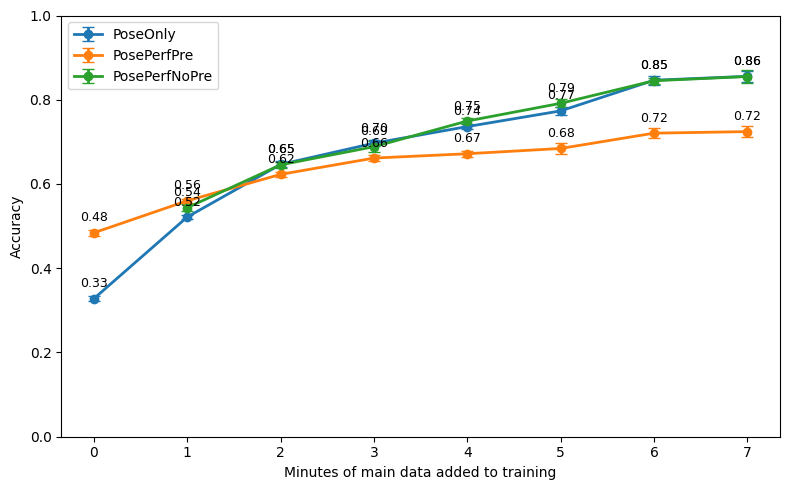

In [ ]:
# --- File paths for the data ---
pose_pre_fp         = "data/linear_pose_metrics/baseline_pose_metrics.csv"      # Baseline pose data
performance_pre_fp  = "data/performance/performance_bsl.csv"                    # Baseline performance data
pose_main_fp        = "data/linear_pose_metrics/experimental_pose_metrics.csv"  # Experimental pose data
performance_main_fp = "data/performance/performance_exp.csv"                    # Experimental performance data

# --- Settings for the analysis ---
center_features  = True         # Whether to center features before training
show_progressbar = True         # Show progress bar during training
n_seeds          = 10           # Number of times to repeat training for reliability
cut_minutes      = range(0, 8)  # Try training with 0 to 7 minutes of experimental data
SKIP_EVERY       = 2            # Use every 2nd data window (because the data from before is 50% overlap, we are only training per minute increment here)

# --- Helper functions to load and process data ---
def load_pose(fp, skip_every):
    # Load pose data from a file, downsample if needed, and add a 'minute' column
    df = pd.read_csv(fp)
    if skip_every:
        df = df[df["window_index"] % skip_every == 0]
    df["participant"] = df["participant"].astype(str)
    df["condition"]   = df["condition"].astype(str)
    df["minute"]      = (df["window_start"] / 60).round().astype(int)
    return df.reset_index(drop=True)

def load_perf(fp, skip_every):
    # Load performance data from a file, downsample if needed, and add a 'minute' column
    df = pd.read_csv(fp)
    if skip_every:
        df = df[df["window_index"] % skip_every == 0]
    df["participant"] = df["participant"].astype(str)
    df["condition"]   = df["condition"].astype(str)
    df["minute"]      = (df["window_start"] / 60).round().astype(int)
    return df.reset_index(drop=True)

def load_and_merge(pose_fp, perf_fp, skip_every):
    # Load pose and performance data, then merge them by participant, condition, and minute
    pose = load_pose(pose_fp, skip_every).copy()
    perf = load_perf(perf_fp, skip_every).copy()
    perf = perf.drop(columns=["window_start","window_end"], errors="ignore")
    merged = pd.merge(
        pose,
        perf,
        on=["participant","condition","minute"],
        how="inner",
        suffixes=("","_perf")
    )
    return merged

# --- Prepare datasets for training ---
pose_pre_df  = load_pose(pose_pre_fp, SKIP_EVERY)   # Baseline pose data
pose_main_df = load_pose(pose_main_fp, SKIP_EVERY)  # Experimental pose data

# Features and labels for baseline pose
X_pose_pre   = pose_pre_df.drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
y_pose_pre   = pose_pre_df["condition"]

# Merged pose+performance datasets
data_model_2_pre  = load_and_merge(pose_pre_fp,  performance_pre_fp,  SKIP_EVERY)
data_model_2_main = load_and_merge(pose_main_fp, performance_main_fp, SKIP_EVERY)

# --- Model setup ---
models = ["PoseOnly","PosePerfPre","PosePerfNoPre"]   # Three model types to compare
metrics = ["BalancedAcc", "F1", "Kappa"]              # Metrics to track for each model
# Prepare a results dictionary to store scores for each model, minute, and metric
results = {model: {m: {metric: [] for metric in metrics} for m in cut_minutes} for model in models}
seed_iter = tqdm(range(n_seeds), desc="Seeds") if show_progressbar else range(n_seeds)

# --- Training Loop ---
for seed in seed_iter:
    for m in cut_minutes:
        cutoff = m * 60  # Convert minutes to seconds

        # 1) Model 1: Use all baseline pose + growing amount of experimental pose
        mask_train = pose_main_df["window_start"] < cutoff
        mask_test  = pose_main_df["window_start"] >= cutoff
        if mask_test.sum()>0:
            X_tr = pd.concat([X_pose_pre, pose_main_df[mask_train].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])])
            y_tr = pd.concat([y_pose_pre, pose_main_df[mask_train]["condition"]])
            X_te = pose_main_df[mask_test].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            y_te = pose_main_df[mask_test]["condition"]

            # Build and train the model pipeline (scaling + random forest)
            pipe = Pipeline([
                ("scaler", StandardScaler(with_mean=center_features)),
                ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1))
            ])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            # Store results for this run
            results["PoseOnly"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
            results["PoseOnly"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
            results["PoseOnly"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

        # 2) Model 2: Use all baseline pose+performance + growing experimental pose+performance
        mask_train = data_model_2_main["window_start"] < cutoff
        mask_test  = data_model_2_main["window_start"] >= cutoff
        if mask_test.sum()>0:
            X_tr = pd.concat([
                data_model_2_pre.drop(columns=["participant","condition","window_index","window_start","window_end","minute"]),
                data_model_2_main[mask_train].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            ])
            y_tr = pd.concat([
                data_model_2_pre["condition"],
                data_model_2_main[mask_train]["condition"]
            ])
            X_te = data_model_2_main[mask_test].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
            y_te = data_model_2_main[mask_test]["condition"]

            pipe = Pipeline([
                ("scaler", StandardScaler(with_mean=center_features)),
                ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1))
            ])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            results["PosePerfPre"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
            results["PosePerfPre"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
            results["PosePerfPre"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

        # 3) Model 3: Only use growing experimental pose (no baseline), start at m>=1
        if m > 0:
            mask_tr = pose_main_df["window_start"] < cutoff
            mask_te = pose_main_df["window_start"] >= cutoff
            if mask_tr.sum() > 0 and mask_te.sum() > 0:
                X_tr = pose_main_df[mask_tr].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
                y_tr = pose_main_df[mask_tr]["condition"]
                X_te = pose_main_df[mask_te].drop(columns=["participant","condition","window_index","window_start","window_end","minute"])
                y_te = pose_main_df[mask_te]["condition"]
                pipe = Pipeline([
                    ("scaler", StandardScaler(with_mean=center_features)),
                    ("rf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1))
                ])
                pipe.fit(X_tr, y_tr)
                y_pred = pipe.predict(X_te)
                results["PosePerfNoPre"][m]["BalancedAcc"].append(balanced_accuracy_score(y_te, y_pred))
                results["PosePerfNoPre"][m]["F1"].append(f1_score(y_te, y_pred, average="weighted"))
                results["PosePerfNoPre"][m]["Kappa"].append(cohen_kappa_score(y_te, y_pred))

# --- Helper to format results for display ---
def format_metric(vals):
    # Show mean and standard deviation for each metric
    return f"{np.mean(vals):.3f} ± {np.std(vals, ddof=1):.3f}"

# --- Print results as a table ---
print("\\begin{tabular}{l|" + "c" * len(cut_minutes) + "}")
header = ["Model/Minute"] + [str(m) for m in cut_minutes]
print(" & ".join(header) + " \\\\ \\hline")

for model in models:
    for metric in metrics:
        if model == "PosePerfNoPre":
            row_minutes = cut_minutes[1:]  # skip 0 for this model
        else:
            row_minutes = cut_minutes

        row = [f"{model} ({metric})"]
        for m in row_minutes:
            vals = results[model][m][metric]
            if vals:
                row.append(format_metric(vals))
            else:
                row.append("--")
        print(" & ".join(row) + " \\\\")
print("\\end{tabular}")

# --- Plot learning curves for each model ---
fig, ax = plt.subplots(figsize=(8,5))
for model in models:
    xs, ys, errs = [], [], []
    for m in cut_minutes:
        if model == "PosePerfNoPre" and m == 0:
            continue
        vals = results[model][m]["BalancedAcc"]
        if not vals:
            continue
        mean = np.mean(vals)
        std  = np.std(vals, ddof=1)
        xs.append(m)
        ys.append(mean)
        errs.append(std)

    ax.errorbar(xs, ys, yerr=errs, label=model, marker="o", capsize=4, lw=2)

    # Annotate each point with the value
    for x, y in zip(xs, ys):
        ax.text(x, y + 0.02, f"{y:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Minutes of main data added to training")
ax.set_ylabel("Accuracy")
ax.set_xticks(list(cut_minutes))
ax.set_ylim(0,1)
ax.legend()
plt.tight_layout()
plt.show()